# DSN BOOTCAMP 2026 ML Track hackathon Getting started notebook 

experimentation notebook by metrosmash

## Phase 1: Importing needed Libraries and Dataset

In [5]:
#Experiment tracking mlflow 
!pip install mlflow xgboost

In [6]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import sqlite3
import mlflow 

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

from sklearn.preprocessing import PowerTransformer

In [7]:
# connection = sqlite3.connect()

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("mean_fillnav0.1.1experiment")

# run this to track using the mlflow UI
# mlflow server --backend-store-uri sqlite:///mlflow.db --port 5000

2026/09/20 12:27:07 INFO mlflow.tracking.fluent: Experiment with name 'mean_fillnav0.1.1experiment' does not exist. Creating a new experiment.


<Experiment: artifact_location=('file:C:/Users/ajibo/Documents/Code/Python_Projects/dsn bootcamp 2026 '
 'hackathon/mlruns/2'), creation_time=1789903627386, effective_trace_archival_retention=None, experiment_id='2', last_update_time=1789903627386, lifecycle_stage='active', name='mean_fillnav0.1.1experiment', tags={}, trace_location=None, workspace='default'>

In [8]:
# major directory file_path.
DIR = "data/"

# specific filepaths
train_path = f"{DIR}train.csv"
test_path = f"{DIR}test.csv"
sample_path = f"{DIR}sample_submission.csv"

# importing the files using pandas read_csv
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample = pd.read_csv(sample_path)


In [9]:
# check the data
# Hide this 
def basic_data(df: DataFrame, name: str, for_y = 0):
    """
    function prints the shape of the data
    """
    if for_y == 0:
        shape = df.shape
        print(f"The {name} dataframe has {shape[0]} Rows and {shape[1]} Columns")
        print('*'* 30)
    else:
        shape = df.shape
        print(f"The {name} dataframe has {shape[0]} Rows")
        print('*'* 30)

In [10]:
basic_data(train, "train")
basic_data(test, "test")
basic_data(sample, "sample_submission")

The train dataframe has 6818 Rows and 13 Columns
******************************
The test dataframe has 1705 Rows and 12 Columns
******************************
The sample_submission dataframe has 1705 Rows and 2 Columns
******************************


### Description of the columns in the train data 
|column|Description|
|------|-----------|
|id| Unique row identifier|
| product_code| Unique code for the product|
|product_weight_kg |	Weight of the product in kilograms (some values are missing)|
|fat_content |	Whether the product is labelled "Low Fat" or "Regular"|
|shelf_visibility |	The proportion of total display area in the store allocated to this product|
|product_category |	The product's category (note: capitalization is inconsistent — that's real-world data, not a bug)|
|product_price |	The product's listed price|
|store_code |	Unique code for the store|
|store_size |	The store's size category: Small, Medium, or Large (some values are missing)|
|store_location_tier |	The tier of the store's location — Tier_1 (major urban centers), Tier_2 (state capitals), Tier_3 (smaller towns)|
|store_format |	The store's format: Corner Shop, Standard Supermarket, Superstore, or Flagship Hypermarket|
|total_sales |	Target. Total sales value for this product at this store (train only)|

## Phase 2: Simple Exploratory data Analysis

In [11]:
# check out the train data 
train.head()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


In [12]:
# print the percentage of missing values in the df per column 
""" we are dividing the total missing values in a column/by the total no of rows 
    then multiplying it by 100 giving the percent missing values if you want the
    total missing values modify the function """
def check_nan_state(df, name):
    total_rows = len(df)
    if total_rows == 0:
        print("Dataframe is empty !!!")
    else:
        nan_percent = (df.isna().sum()/ total_rows * 100).round(2)
        nan_percent_display = pd.DataFrame({"Column" : nan_percent.index,
                                            "Percent missing" : nan_percent.values}).sort_values("Percent missing"
                                                                                                 , ascending = False)
        print(f"Percent values of NAN values in {name} dataframe ")
        display(nan_percent_display)

In [13]:
check_nan_state(train, "train")

Percent values of NAN values in train dataframe 


,Column,Percent missing
9,store_size,28.15
2,product_weight_kg,17.97
0,id,0.00
3,fat_content,0.00
1,product_code,0.00
4,shelf_visibility,0.00
5,product_category,0.00
7,store_code,0.00
6,product_price,0.00
8,store_age_years,0.00


In [14]:
# check out the statistical distribution of the numerical columns in the df
train.describe()

,product_weight_kg,shelf_visibility,product_price,store_age_years,total_sales
count,5593.000000,6818.000000,6818.000000,6818.000000,6818.000000
mean,12.850876,0.065527,140.473623,34.178205,2174.756574
std,4.646542,0.051566,62.413513,8.384574,1697.894956
min,4.482000,0.000000,31.110000,23.000000,32.700000
25%,8.750000,0.026600,93.280000,28.000000,834.792500
50%,12.647000,0.053200,142.065000,33.000000,1790.890000
75%,16.894000,0.093400,185.987500,45.000000,3092.587500
max,21.883000,0.320100,273.040000,47.000000,12996.820000


notice that spike from 75% percentile total sales of 3k to 100% percentile total sales of 12k some thing is there

- the 12k total sales is  under `HOUSEHOLD`, `fruitsandvegitables` in product_category
- we also have 10k total sales under `Dairy` in the product_category i would do a more indepth search on this spike it might be outliers

now checking from store formats this follows normal conventions 
|store_format|   total_sales |
|------------|------------------|
|Corner Shop  |            1830.37|
|Flagship Hypermarket |   12996.82|
|Standard Supermarket |   10130.90|
|Superstore          |     7016.22|


In [11]:
total_sales_groupby = train.groupby("product_category")["total_sales"].max()
total_sales_groupby

product_category
BAKING GOODS              7720.12
BREADS                    5897.21
BREAKFAST                 7125.94
Baking Goods              6745.85
Breads                    9258.66
Breakfast                 6405.06
CANNED                    8247.44
Canned                    7556.65
DAIRY                     7778.41
Dairy                    10477.97
FROZEN FOODS              8894.14
FRUITS AND VEGETABLES     9564.04
Frozen Foods              9072.04
Fruits and Vegetables    12359.04
HARD DRINKS               8141.49
HEALTH AND HYGIENE        6940.39
HOUSEHOLD                12996.82
Hard Drinks               7299.20
Health and Hygiene        8282.96
Household                 7827.35
MEAT                      9192.48
Meat                      9403.18
OTHERS                    6204.86
Others                    5805.06
SEAFOOD                   6138.02
SNACK FOODS               7393.24
SOFT DRINKS               6811.73
STARCHY FOODS             6898.82
Seafood                   4521.

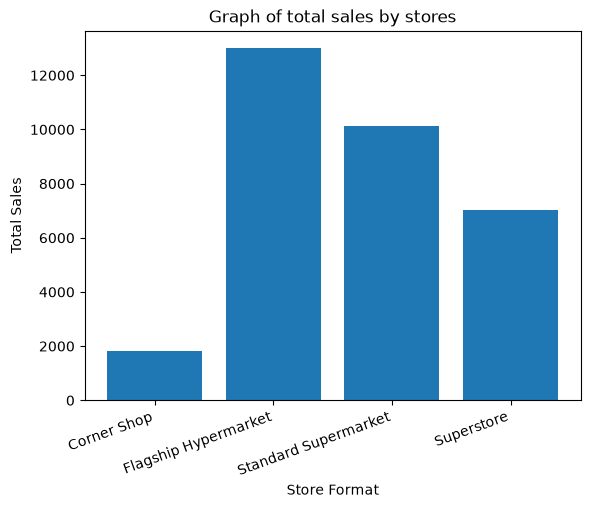

In [12]:
store_format_by_total_sales = train.groupby("store_format")["total_sales"].max()
# store_format_by_total_sales

index = store_format_by_total_sales.index
values = store_format_by_total_sales.values

plt.bar(index, values)
plt.xticks(
    ticks=range(len(index)),
    rotation=20,
    ha = "right"
)
plt.xlabel("Store Format")
plt.ylabel("Total Sales")
plt.title("Graph of total sales by stores")
plt.show()

In [13]:
# hiding this for now 
# train["shelf_visibility_bins"] = pd.qcut(train["shelf_visibility"], 5 )

In [14]:
train_shelf_visibility_total_sales = train.groupby('shelf_visibility_bins')["total_sales"].max()

KeyError: 'shelf_visibility_bins'

In [ ]:
train_shelf_visibility_total_sales

In [ ]:

fig, ax = plt.subplots(figsize=(8, 5))
train_shelf_visibility_total_sales.plot(kind='bar', ax=ax, color='skyblue', edgecolor='black')
ax.set_title('Total Sales by Shelf Visibility Bin')
ax.set_xlabel('Shelf Visibility Bins')
ax.set_ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
print("total sales distribution:")
print(f"  Mean:     {train['total_sales'].mean():.2f}")
print(f"  Median:   {train['total_sales'].median():.2f}")
print(f"  Max:      {train['total_sales'].max():.2f}")
print(f"  Skewness: {train['total_sales'].skew():.2f}  ← Somewhat skewed")
print()
print("After log1p transform:")
print(f"  Skewness: {np.log1p(train['total_sales']).skew():.2f}  ← much better")

In [ ]:
# Original emission values
original = train["total_sales"]

# Log-transformed values
log_transformed = np.log1p(original)

# Create figure
plt.figure(figsize=(12, 5))

# Original distribution
plt.subplot(1, 2, 1)
plt.hist(original, bins=40)
plt.title("Original total_sales Distribution")
plt.xlabel("total_sales")
plt.ylabel("Frequency")

# Log-transformed distribution
plt.subplot(1, 2, 2)
plt.hist(log_transformed, bins=40)
plt.title("Log1p Transformed Distribution")
plt.xlabel("log1p(total_sales)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Print statistics
print("Original skewness:", round(original.skew(), 2))
print("Log1p skewness:", round(log_transformed.skew(), 2))

In [ ]:
# Original emission values
original = train["total_sales"]

# Log-transformed values
log_transformed = np.sqrt(original)

# Create figure
plt.figure(figsize=(12, 5))

# Original distribution
plt.subplot(1, 2, 1)
plt.hist(original, bins=40)
plt.title("Original Emission Distribution")
plt.xlabel("Emission")
plt.ylabel("Frequency")

# Log-transformed distribution
plt.subplot(1, 2, 2)
plt.hist(log_transformed, bins=40)
plt.title("sqrt Transformed Distribution")
plt.xlabel("sqrt(Emission)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Print statistics
print("Original skewness:", round(original.skew(), 2))
print("sqrt skewness:", round(log_transformed.skew(), 2))

In [ ]:
# Original values
original = train["total_sales"]

# Yeo-Johnson transformed values
pt = PowerTransformer(method='yeo-johnson')
yj_transformed = pt.fit_transform(original.values.reshape(-1, 1)).flatten()

# Create figure
plt.figure(figsize=(12, 5))

# Original distribution
plt.subplot(1, 2, 1)
plt.hist(original, bins=40)
plt.title("Original total_sales Distribution")
plt.xlabel("total_sales")
plt.ylabel("Frequency")

# Yeo-Johnson transformed distribution
plt.subplot(1, 2, 2)
plt.hist(yj_transformed, bins=40)
plt.title("Yeo-Johnson Transformed Distribution")
plt.xlabel("yeo_johnson(total_sales)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Print statistics
print("Original skewness:", round(original.skew(), 2))
print("Yeo-Johnson skewness:", round(pd.Series(yj_transformed).skew(), 2))
print("Fitted lambda:", round(pt.lambdas_[0], 4))

## Phase 3: Data Preprocessing 

In [15]:
"""
we know that two columns are have nan values and also that a column has 
inconsistent capitalization so we create functions to clean this 

"""
def normalize_capitalization(df, old_column, new_column):
    """
    Normalizes case/whitespace duplicates in a categorical column
    (e.g. 'seafood', 'SEAFOOD', 'SeaFood' -> 'seafood') and writes
    the result into a new column.
    
    params: 
    df - your dataframe
    old_column - column with inconsistent capitalization
    new_column - column with corrected capitalization
    """
    df = df.copy()
    df[new_column] = (df[old_column]
        .astype(str)
        .str.strip()
        .str.lower())
    
    return df

def mean_fillna(df, column):
    """
    we fill the nan values using the mean(average) value 
    """
    overall_mean = df[column].mean()
    df[column] = df[column].fillna(overall_mean)

    return df 

def mode_fillna(df, column):
    """
    we fill the nan values using the most frequent(mode) value 
    """
    #mode returns a series so we pick the first value
    overall_mode = df[column].mode()[0]
    df[column] = df[column].fillna(overall_mode)
    
    return df 
    
def encode_fat_content(df):
    """
    we encode the fat_content column since its just two cat columns
    """
    # df['encoded_fat_content'] = df["fat_content"].map({"Regular":1,"low fat":0}) # Another way to do the bellow function in one line
    # 0 = low fat
    # 1 = regular
    df = df.copy()
    df["encoded_fat_content"] = 0
    df.loc[df.fat_content == "Regular" , "encoded_fat_content"] = 1
    
    return df 

def encode_columns(df, columns_list):
    """
    explain this
    """
    df = pd.get_dummies(df,columns = encode_column_list, drop_first = True, dtype = int)
    print(df.info())
    
    return df 

def encode_store_location_tier(df):
    """
    explain this
    """
    # this is an Ordinal data tier 1 is best to tier 3 worse
    # might use this for three-based models
    # 0 = tier one
    # 1 = tier two
    # 2 = tier three
    df = df.copy()
    df["encoded_store_location_tier"] = 0
    df.loc[df.store_location_tier == "Tier_2" , "encoded_store_location_tier"] = 1
    df.loc[df.store_location_tier == "Tier_3" , "encoded_store_location_tier"] = 2
    
    return df 

def encode_store_size(df):
    """
    explain this
    """
    # this is an Ordinal data 
    # might use this for three-based models
    # 0 = small
    # 1 = medium
    # 2 = large
    df = df.copy()
    df["encoded_store_size"] = 0
    df.loc[df.store_size == "Medium" , "encoded_store_size"] = 1
    df.loc[df.store_size == "Large" , "encoded_store_size"] = 2
    
    return df 

In [16]:
"""
noticed that in the store_format column the flagship Hypermarket column has no product_weight_kg column values all nans 
so came up with the idea to calculate the average mean of each product_codes to be very precise in the filling of the nan value 
"""
def fit_weight_maps(train, code_col='product_code', category_col='product_category',
                     weight_col='product_weight_kg', exclude_col='store_format',
                     exclude_val='Flagship Hypermarket'):
    reference = train[train[exclude_col] != exclude_val]
    code_map = reference.groupby(code_col)[weight_col].mean().round(3)
    category_map = reference.groupby(category_col)[weight_col].mean().round(3)
    overall_mean = round(reference[weight_col].mean(), 3)
    return code_map, category_map, overall_mean


def apply_weight_fill(df, code_map, category_map, overall_mean, 
                       code_col='product_code', category_col='cleaned_product_category', 
                       weight_col='product_weight_kg'):
    filled = df[weight_col].fillna(df[code_col].map(code_map))

    still_na = filled.isna()
    filled[still_na] = df.loc[still_na, category_col].map(category_map)

    still_na = filled.isna()
    filled[still_na] = overall_mean

    df[weight_col] = filled
    return df

# # Fit once on train
# code_map, category_map, overall_mean = fit_weight_maps(train)

# # Apply to both using the same fitted maps
# train = apply_weight_fill(train, code_map, category_map, overall_mean)
# test = apply_weight_fill(test, code_map, category_map, overall_mean)

In [17]:
drop_column_list = ["id", "product_category","product_code", "store_code"]
encode_column_list = ["cleaned_product_category","store_format","fat_content","store_size","store_location_tier"]

# Fit once on train - outside of the clean_df function for a reason 
# code_map, category_map, overall_mean = fit_weight_maps(train)

# check out using log1 for transform_sales 
def clean_df(df, drop_column_list, encode_column_list, code_map, category_map, overall_mean):
    """
    Combining all those functions to a simple pipeline to clean a dataframe
    """
    print(f"{"*" * 15} normalizing the inconsistent capitalizations{"*" * 15}")
    df = normalize_capitalization(df, "product_category", "cleaned_product_category")
    print(f"{"*" * 15} filling the nan values in product_weight_kg column{"*" * 15}")
    df = apply_weight_fill(df, code_map, category_map, overall_mean)
    print(f"{"*" * 15} filling the nan values in store_size column{"*" * 15}")
    df = mode_fillna(df, "store_size")
    
    # print(f"{"*" * 15} encoding the fat content column{"*" * 15}") # reduces the overall rmse score for all models so i didnt use it
    # df = encode_fat_content(df)
    # print(f"{"*" * 15} encoding the store location_tier column{"*" * 15}")
    # df = encode_store_location_tier(df)
    # print(f"{"*" * 15} encoding the store_size column{"*" * 15}")
    # df = encode_store_size(df)    
    print(f"{"*" * 15} droping un-needed columns{"*" * 15}")
    df = df.drop(columns = drop_column_list)
    print(f"{"*" * 15} encoding other columns {"*" * 15}")
    df = encode_columns(df, encode_column_list)

    return df 
    

In [18]:
# Fit once on train - outside of the clean_df function for a reason 
code_map, category_map, overall_mean = fit_weight_maps(train)
trainX = clean_df(train, drop_column_list, encode_column_list, code_map, category_map, overall_mean)

*************** normalizing the inconsistent capitalizations***************
*************** filling the nan values in product_weight_kg column***************
*************** filling the nan values in store_size column***************
*************** droping un-needed columns***************
*************** encoding other columns ***************
<class 'pandas.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 28 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   product_weight_kg                               6818 non-null   float64
 1   shelf_visibility                                6818 non-null   float64
 2   product_price                                   6818 non-null   float64
 3   store_age_years                                 6818 non-null   int64  
 4   total_sales                                     6818 non-null   float64
 5   cleaned_product

## Phase 4: Spliting the train dataframe 
we split the train_data into train and validation

test the validation against the kaggle score an up in the validation should be an up on the kaggle score 
then we use the spit for experimentation and testing- (might use mlflow to track experiments)

In [19]:
target = "total_sales"
train_y = trainX[target]
train_X = trainX.drop(columns = target)
# using 0.3 for now thats about 2045 rows for validation my switch to cross-validation later
train_dfX, val_dfX, train_dfy, val_dfy = train_test_split(train_X, train_y, test_size = 0.3, random_state = 43)

In [20]:
basic_data(train_dfX, "train_df X")
basic_data(train_dfy, "train_df y", for_y = 1)
basic_data(val_dfX, "validation_df X")
basic_data(val_dfy, "validation_df y", for_y = 1)

The train_df X dataframe has 4772 Rows and 27 Columns
******************************
The train_df y dataframe has 4772 Rows
******************************
The validation_df X dataframe has 2046 Rows and 27 Columns
******************************
The validation_df y dataframe has 2046 Rows
******************************


In [26]:
## transform the target column here 
def log1p(series):
    series = np.log1p(series)

    return series

def sqrt(series):
    series = np.sqrt(series)

    return series 

def yeo_john_trans(series):
    # Yeo-Johnson transformed values
    pt = PowerTransformer(method='yeo-johnson')
    series = pt.fit_transform(series.values.reshape(-1, 1)).flatten()

    return series
    
train_dfy = sqrt(train_dfy)

In [27]:
def convert_back(series):
    # series = np.expm1(series) # for log1p()
    series = np.square(series) # for sqrt
    # series = pt.inverse_transform(series.reshape(-1, 1)).flatten() # for yeo johnson
    
    return series

### Phase 5: Fitting the model 
comparing linear regression model, random forest regressor and xgboost regressor

In [21]:
def compute_metric(y_true, y_pred, name):
    
    rmse_val = round(root_mean_squared_error(y_true, y_pred), 5)
    mae_val = round(mean_absolute_error(y_true, y_pred), 5)
    rmse_name = f"{name} rmse"
    mae_name = f"{name} mae"
    
    print(f"{rmse_name}: {rmse_val}")
    print(f"{mae_name}: {mae_val}")

    return rmse_val, rmse_name, mae_val, mae_name

In [28]:
# still in the works but should increase the spead of experimentation by a lot 

def fit_score_log(train_X, train_y,val_X, val_y, model,model_name, note_for_tag: dict, params = None, xgb_present = False):
    # Start an MLflow run
    with mlflow.start_run():
        # Log the hyperparameters
        if params is not None:
            mlflow.log_params(params)
            
        # Train the model
        # lr = LogisticRegression(**params) # this would be done outside the function by me 
    
        model.fit(train_X, train_y)
        
    
        # Log the model
        if xgb_present == True:
            model_info = mlflow.xgboost.log_model(xgb_model= model, name= model_name)
        else:
            model_info = mlflow.sklearn.log_model(sk_model= model, name= model_name)
    
        # Predict on the test set, compute and log the loss metric
        model_pred = model.predict(val_X)
        # convert the transformed predicted value back for metric
        model_pred = convert_back(model_pred)
        
        rmse_metric_value, rmse_metric_name, mae_metric_value, mae_metric_name  = compute_metric(val_y, model_pred, model_name)
        mlflow.log_metric(rmse_metric_name, rmse_metric_value)
        mlflow.log_metric(mae_metric_name, mae_metric_value)
    
        # Optional: Set a tag that we can use to remind ourselves what this run was for
        mlflow.set_tag(note_for_tag["name"], note_for_tag["tag"])

In [44]:
lmodel = LinearRegression()
model_name = "Linear_regressionv0-1-1_target_transform_test"
note_for_tag = {"name":"linear model test","tag":"target_transform_test"}
fit_score_log(train_dfX, train_dfy, val_dfX, val_dfy,  lmodel, model_name, note_for_tag)

Linear_regressionv0-1-1_target_transform_test rmse: 1099.4435
Linear_regressionv0-1-1_target_transform_test mae: 767.9445


In [30]:
rfmodel = RandomForestRegressor()
model_name = "randomForest_regressorv0-1-1_target_transform_test"
note_for_tag = {"name":"random forest regresror test","tag":"target_transform_test"}
fit_score_log(train_dfX, train_dfy, val_dfX, val_dfy,  rfmodel, model_name, note_for_tag)

randomForest_regressorv0-1-1_target_transform_test rmse: 1138.39524
randomForest_regressorv0-1-1_target_transform_test mae: 779.3061


In [31]:
xgbmodel = XGBRegressor()
model_name = "xgbregressor0-1-1_target_transform_test"
note_for_tag = {"name":"xgbregressor test","tag":"target_transform_test"}
fit_score_log(train_dfX, train_dfy, val_dfX, val_dfy,  xgbmodel, model_name, note_for_tag, xgb_present = True)

xgbregressor0-1-1_target_transform_test rmse: 1172.4842
xgbregressor0-1-1_target_transform_test mae: 810.29942


In [36]:
rf_model = RandomForestRegressor()
rf_model.fit(train_X, train_y)
# quick check, assuming a tree-based model
FEATURES = train_dfX.columns
importances = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(importances)

product_price                                     0.433576
store_format_Flagship Hypermarket                 0.107237
store_format_Standard Supermarket                 0.099381
product_weight_kg                                 0.096740
shelf_visibility                                  0.089250
store_age_years                                   0.044537
store_format_Superstore                           0.037463
cleaned_product_category_snack foods              0.008531
cleaned_product_category_fruits and vegetables    0.008459
fat_content_Regular                               0.008372
cleaned_product_category_household                0.006395
cleaned_product_category_dairy                    0.006285
store_size_Small                                  0.006007
cleaned_product_category_frozen foods             0.005600
cleaned_product_category_soft drinks              0.005588
cleaned_product_category_canned                   0.004802
cleaned_product_category_health and hygiene       0.0046

In [35]:
xgb_model = XGBRegressor()
xgb_model.fit(train_X, train_y)
# quick check, assuming a tree-based model
FEATURES = train_dfX.columns
importances = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(importances)

store_format_Flagship Hypermarket                 0.358360
store_format_Standard Supermarket                 0.258798
product_price                                     0.065616
store_age_years                                   0.049779
cleaned_product_category_starchy foods            0.019741
cleaned_product_category_soft drinks              0.016724
cleaned_product_category_snack foods              0.016011
cleaned_product_category_breads                   0.015562
cleaned_product_category_hard drinks              0.014429
cleaned_product_category_seafood                  0.013918
cleaned_product_category_household                0.013840
cleaned_product_category_fruits and vegetables    0.013795
store_location_tier_Tier_3                        0.012765
cleaned_product_category_dairy                    0.012602
shelf_visibility                                  0.011448
product_weight_kg                                 0.011261
store_size_Medium                                 0.0112

#### Score board
- cleandf with target_encode 3 value_count categorical columns, no params models
linear regression model(no params)- plain clean df function(most features target encoded)
{Linear_regressionv0-1_test rmse: 1137.03769, Linear_regressionv0-1_test mae: 843.71453}

{random forest regressor model(no params) - plain clean df function(most features target encoded){random Forest re v0.2 rmse: 1133.89521,
random Forest re v0.2 mae: 781.5996}

{xgbregressor0-1-1_target_transform_test rmse: 1192.48004 , xgbregressor0-1-1_target_transform_test mae: 833.33377}

------
- Log1p() transform of the target data (no params (mostly target encoded features)) (the model sees the mid-range values more but makes more errors on the big-range values)

{Linear_regressionv0-1-1_target_transform_test rmse: 1159.28224, Linear_regressionv0-1-1_target_transform_test mae: 787.90402}
{randomForest_regressorv0-1-1_target_transform_test rmse: 1159.02768, randomForest_regressorv0-1-1_target_transform_test mae: 786.92395}
{xgbregressor0-1-1_target_transform_test rmse: 1183.47615, xgbregressor0-1-1_target_transform_test mae: 812.26741}

-------
- sqrt() transform of the target data (no params (mostly target encoded features)) (seems better for linear model with some progress for tree)
{Linear_regressionv0-1-1_target_transform_test rmse: 1100.38495, Linear_regressionv0-1-1_target_transform_test mae: 768.32231}

{randomForest_regressorv0-1-1_target_transform_test rmse: 1129.6338, randomForest_regressorv0-1-1_target_transform_test mae: 773.80828}

{xgbregressor0-1-1_target_transform_test rmse: 1203.40741, xgbregressor0-1-1_target_transform_test mae: 825.85441}

-------
- yeo-johnson power transform of the target data (no params (mostly target encoded features)) (better for mae little but not much )
{Linear_regressionv0-1-1_target_transform_test rmse: 1108.74139, Linear_regressionv0-1-1_target_transform_test mae: 765.32926}

{randomForest_regressorv0-1-1_target_transform_test rmse: 1145.16519, randomForest_regressorv0-1-1_target_transform_test mae: 778.25574}

{xgbregressor0-1-1_target_transform_test rmse: 1181.41153, xgbregressor0-1-1_target_transform_test mae: 807.34138}

--------
sqrt() transform with target data (no params(not-target encoded features))
{Linear_regressionv0-1-1_target_transform_test rmse: 1099.43378, Linear_regressionv0-1-1_target_transform_test mae: 767.9085}

## Phase 6: fitting for the kaggle leaderboard

In [59]:
trainX.info()
yy = trainX["total_sales"]

y = sqrt(yy)
X = trainX.drop(columns = ["total_sales"])

<class 'pandas.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 28 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   product_weight_kg                               6818 non-null   float64
 1   shelf_visibility                                6818 non-null   float64
 2   product_price                                   6818 non-null   float64
 3   store_age_years                                 6818 non-null   int64  
 4   total_sales                                     6818 non-null   float64
 5   cleaned_product_category_breads                 6818 non-null   int64  
 6   cleaned_product_category_breakfast              6818 non-null   int64  
 7   cleaned_product_category_canned                 6818 non-null   int64  
 8   cleaned_product_category_dairy                  6818 non-null   int64  
 9   cleaned_product_category_frozen foods           6818

In [60]:
# using the code_map, category_map, and overall_mean of train
testX = clean_df(test, drop_column_list, encode_column_list, code_map, category_map, overall_mean)

*************** normalizing the inconsistent capitalizations***************
*************** filling the nan values in product_weight_kg column***************
*************** filling the nan values in store_size column***************
*************** droping un-needed columns***************
*************** encoding other columns ***************
<class 'pandas.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 27 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   product_weight_kg                               1705 non-null   float64
 1   shelf_visibility                                1705 non-null   float64
 2   product_price                                   1705 non-null   float64
 3   store_age_years                                 1705 non-null   int64  
 4   cleaned_product_category_breads                 1705 non-null   int64  
 5   cleaned_product

In [61]:
kaggle_lr = LinearRegression()

kaggle_lr.fit(X, y)

kaggle_pred = kaggle_lr.predict(testX)
kaggle_pred = convert_back(kaggle_pred)

In [62]:
kaggle_pred.shape

(1705,)

In [63]:
sample_df = sample

sample_df["total_sales"] = kaggle_pred.round(2)

In [64]:
sample_df.to_csv("linear_model_no_params_changed_clean_df_sqrt_target.csv", index=False)

In [65]:
sample_df.head()

,id,total_sales
0,row_00009,2497.29
1,row_00015,4333.26
2,row_00019,2876.59
3,row_00020,2943.51
4,row_00023,2171.28


### kaggle to validation split checking 
- on linear regression model split one (5:30 am/15th)
local validation checking is at 1136.4627914455766 - kaggle leaderboard checking is at 1124.05746
- on linear regression model split two (5:57am/15th)(clean_df changed added label encode for other tiers)
local validation checking is at 1137.03769 - kaggle leader board checking is at 1125.63170

- on linear regression model sqrt transform (6:15, 19th) - local is 1099.43378 - kaggle leaderboard checking is at 1102.41711
